In [1]:
import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import glob 
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
import matplotlib.patches as mpatches
import seaborn as sns 
import copy
import numpy as np 
import os
import scipy.stats
import time 
import json
import pickle
import sys

from config import home_path, llm_review_path, figure_path_2, supp_table_path
sys.path.insert(1, home_path) 
from common_functions import (
    my_colors, 
    format_p, 
    get_pfam_info, 
    mean_confidence_interval, 
    entropy, 
    sort_dict_by_value
)

from scipy.spatial.distance import jensenshannon
from sklearn import metrics

/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:

def save_figure(fig, name, root_path = figure_path_2, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")

In [3]:
vogelstein = pd.read_csv(llm_review_path + "data/Vogelstein2013_125drivers_sequences.csv", index_col = 0)
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']
reg_aa_set = set(regular_aas)

model_info = pd.read_csv("model_info.txt", delimiter = "\t")
model_info

display_names = dict(zip(model_info["model_string"], model_info["display_name"]))

green_1 = "#357847"
coral_1 = "#E39695"
dark_blue_1 = "#2B2D42"
dark_red_1 = "#A3320B"
light_blue_1 = "#0C7489"

ur_50_color = dark_red_1
ur_90_color = "seagreen"
ur_100_color = "dodgerblue"


model_list = [
    "esm_1_43M", 
    "esm_1_UR100", 
    "esm_1v", 
    "esm_2_35M", 
    "esm_2_8M",
    "esm_1_85M", 
    "esm_1_UR50", 
    "esm_2_150M", 
    "esm_2_3B", 
    "protbert",
    "esm_1b", 
    "esm_1_UR50D", 
    "esm_2_15B", 
    "esm_2_650M"
]


model_to_dataset = {
    "esm_1_43M" : "UR50",
    "esm_1_UR100" : "UR100",  
    "esm_1v": "UR90", 
    "esm_2_35M" : "UR50", 
    "esm_2_8M" : "UR50",
    "esm_1_85M" : "UR50",
    "esm_1_UR50" : "UR50",
    "esm_2_150M" : "UR50",
    "esm_2_3B" : "UR50",
    "protbert" : "UR100",
    "esm_1b" : "UR50",
    "esm_1_UR50D" : "UR50",
    "esm_2_15B" : "UR50",
    "esm_2_650M" : "UR50",
}

model_to_dataset_str = {
    "esm_1_43M" : "UR50",
    "esm_1_UR100" : "UR100",  
    "esm_1v": "UR90", 
    "esm_2_35M" : "UR50", 
    "esm_2_8M" : "UR50",
    "esm_1_85M" : "UR50",
    "esm_1_UR50" : "UR50S",
    "esm_2_150M" : "UR50",
    "esm_2_3B" : "UR50",
    "protbert" : "UR100",
    "esm_1b" : "UR50",
    "esm_1_UR50D" : "UR50D",
    "esm_2_15B" : "UR50",
    "esm_2_650M" : "UR50",
}

dataset_to_color = {"UR50" : ur_50_color, "UR90" : ur_90_color, "UR100" : ur_100_color, "UR50S" : ur_50_color, "UR50D" : ur_50_color,}

model_to_color = {m : dataset_to_color[model_to_dataset[m]] for m in model_list}
model_to_dataset_string = dict(zip(model_info["model_string"], model_info["dataset_string"]))
model_to_params_string = dict(zip(model_info["model_string"], model_info["params_string"]))
model_to_base_string = dict(zip(model_info["model_string"], model_info["base_string"]))

substitutions = {"esm_1_43M_UR50S" : "esm_1_43M", "esm_1_85M_UR50S" : "esm_1_85M", "esm_1_UR50S" : "esm_1_UR50", "esm_2": "esm_2_3B"}


for k,v in substitutions.items():
    
    model_to_dataset_string[v] = model_to_dataset_string[k]
    model_to_params_string[v] = model_to_params_string[k]
    model_to_base_string[v] = model_to_base_string[k]
    
    del model_to_dataset_string[k]
    del model_to_params_string[k]
    del model_to_base_string[k]
    


In [4]:
def compute_alignment_counts(hsps, gene, use_pseudocount =True):
    regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']
    reg_aa_set = set(regular_aas)
    reference_seq = vogelstein.loc[vogelstein["gene"] == gene].iloc[0]["sequence"]
    positional_counts = {}

    for i, aa in enumerate(reference_seq):
        if use_pseudocount:
            positional_counts[i + 1] = {reg_aa : 1 for reg_aa in regular_aas}
        else:
            positional_counts[i + 1] = {reg_aa : 0 for reg_aa in regular_aas}

    for i5, hsp in hsps.iterrows():
        qseq = hsp["qseq"]
        hseq = hsp["hseq"]
        query_from = hsp["query_from"]

        pos = query_from - 1
        assert len(qseq) == len(hseq)
        for aa, aln_aa in zip(qseq, hseq):
            if aa != "-":
                assert aa == reference_seq[pos] # 0 indexed 
                
                if aln_aa != "-" and aln_aa in reg_aa_set:
                    positional_counts[pos + 1][aln_aa] += 1 # 1 indexed 
                
                pos += 1

    return positional_counts

def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df

def p_val_to_stars(p):
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return "ns"


In [5]:
USE_PRELOAD = True 
dataset_list = ["UR50", "UR90", "UR100",]

if USE_PRELOAD:
    with open("vogelstein_hsp_dfs_all_datasets.pkl", "rb") as f:
        dataset_to_protein_hsps = pickle.load(f)
    f.close()
else:
    
    dataset_to_protein_hsps = {d : {} for d in dataset_list}

    for dataset in dataset_list:
        print(dataset)
        alignment_results_path = "../../vogelstein/homolog_searches/results/" + dataset + "/"
        aln_files = glob.glob(alignment_results_path + "*.json")
        for i , aln_fn in enumerate(aln_files):

            with open(aln_fn, "r") as f2:
                data = json.load(f2)
            f2.close()

            protein_id = aln_fn.replace(alignment_results_path, "").replace(".json", "")
            reference_seq = vogelstein.loc[vogelstein["gene"] == protein_id].iloc[0]["sequence"]

            if len(reference_seq) > 1022:
                continue 

            query = data["BlastOutput2"][0]
            hits = query["report"]["results"]["search"]["hits"]
            qlen = query["report"]["results"]["search"]["query_len"]

            all_hsps = []
            for hit in hits:
                hsps = hit["hsps"]
                for hsp in hsps:
                    all_hsps.append(hsp)

            hsp_df = pd.DataFrame(all_hsps)
            hsp_df["percent_identity"] = hsp_df["identity"] / (hsp_df["align_len"] - hsp_df["gaps"])
            hsp_df["percent_gaps"] = hsp_df["gaps"] / hsp_df["align_len"] 
            hsp_df["alignment_frac"] = hsp_df["align_len"] / qlen
            dataset_to_protein_hsps[dataset][protein_id] = hsp_df
            
    with open("vogelstein_hsp_dfs_all_datasets.pkl", "wb") as f:
        pickle.dump(dataset_to_protein_hsps, f)
    f.close()

In [6]:
PCT_IDENT = 0.0
GAP_PCT = 0.75
ALN_FRAC = 0.75  

USE_PSEUDOCOUNT = True

dataset_to_protein_aln_counts = {d : {} for d in dataset_list}
dataset_to_protein_site_entropy = {d : {} for d in dataset_list}
homolog_tracker = {d : {} for d in dataset_list}

for d in dataset_list:
    db_dfs = dataset_to_protein_hsps[d]
    for protein_id, dfc in db_dfs.items():
        
        dfc_2 = dfc.loc[
            (dfc["percent_identity"] >= PCT_IDENT) & 
            (dfc["alignment_frac"] >= ALN_FRAC) & 
            (dfc["percent_gaps"] <= GAP_PCT) &
            (dfc["evalue"] < 1e-5)
        ]
        
        homolog_tracker[d][protein_id] = len(dfc_2)
        
        protein_aln_counts = compute_alignment_counts(dfc_2, protein_id, use_pseudocount = USE_PSEUDOCOUNT)
        dataset_to_protein_aln_counts[d][protein_id] = protein_aln_counts
        
        positional_entropies = {}
        for i, count_dict in protein_aln_counts.items():
            v1 = np.asarray(list(count_dict.values()))
            observations = np.sum(v1)
            count_probabilities = v1 / observations
            pos_entropy = entropy(count_probabilities)
            positional_entropies[i] = pos_entropy
        
        dataset_to_protein_site_entropy[d][protein_id] = positional_entropies

In [7]:

USE_PRELOAD = True

if USE_PRELOAD:
    with open("model_to_protein_site_entropy_vogelstein.pkl", "rb") as f:
        model_to_protein_site_entropy = pickle.load(f)
    f.close()
else:
    model_to_protein_site_entropy = {}

    for model in model_list:
        print(model)
        mlm_path = llm_review_path + "masked_results/vogelstein_2013/" + model + "/*.csv.gz"
        mlm_files = glob.glob(mlm_path)

        protein_to_site_entropy = {}

        for fn in mlm_files:
            mlm_df = pd.read_csv(fn)
            mlm_df = augment_masked_df_with_site_entropy(mlm_df)
            gene = mlm_df.iloc[0]["gene"]
            positional_df = mlm_df.drop_duplicates(subset = "aa_pos") # all entropy vals for each position are identical
            site_entropies = dict(zip(positional_df["aa_pos"].values, positional_df["site_entropy"].values))
            protein_to_site_entropy[gene] = site_entropies

        model_to_protein_site_entropy[model] = protein_to_site_entropy

    with open("model_to_protein_site_entropy_vogelstein.pkl", "wb") as f:
        pickle.dump(model_to_protein_site_entropy, f)
    f.close()

In [8]:
conservation_df = []
for model, protein_to_site_entropy in model_to_protein_site_entropy.items():
    for k, v in protein_to_site_entropy.items():
        x = []
        y = []    
        for pos, positoinal_entropy in v.items():
            x.append(positoinal_entropy)
            y.append(dataset_to_protein_site_entropy[model_to_dataset[model]][k][pos])

        pearson_corr, pearson_p = scipy.stats.pearsonr(x,y)
        spearman_corr, spearman_p = scipy.stats.spearmanr(x,y)
        conservation_df.append([k, pearson_corr, pearson_p, spearman_corr, spearman_p, np.mean(x), np.mean(y), model])

conservation_df = pd.DataFrame(conservation_df, columns = ["gene", "pearson r", "pearson p","spearman r", "spearman p", "mean_masked_entropy", "mean_alignment_entropy", "model"])
conservation_df["homologs_UR50"] = conservation_df["gene"].apply(lambda x : homolog_tracker["UR50"][x])
conservation_df["homologs_UR90"] = conservation_df["gene"].apply(lambda x : homolog_tracker["UR90"][x])
conservation_df["homologs_UR100"] = conservation_df["gene"].apply(lambda x : homolog_tracker["UR100"][x])
conservation_df = conservation_df.loc[conservation_df["homologs_UR50"] > 1]


cutoff = 0.0 # includes all 
valid_genes = []

for g, sub_df in conservation_df.groupby("gene"):
    m1 = np.max(sub_df["spearman r"])
    if m1 >= cutoff:
        valid_genes.append(g)

conservation_df = conservation_df.loc[conservation_df["gene"].isin(valid_genes)]

print(len(set(conservation_df["gene"])))

/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4464: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


71


In [9]:
data = []

x_ticklabels = []

model_to_median_entropy = {model : np.median(sub_df["spearman r"]) for (model, sub_df) in conservation_df.groupby("model")}
model_to_median_entropy = sort_dict_by_value(model_to_median_entropy, reverse = True)
dataset_str_list = []
params_str_list = []
text_color_list = []

my_pal = {}

model_order = []
for i, model in enumerate(model_to_median_entropy.keys()):
    sub_df = conservation_df.loc[conservation_df["model"] == model]
    data.append(sub_df["spearman r"].values)
    label_str = (
        model_to_base_string[model]  
    )
    params_str_list.append( model_to_params_string[model]  )
    model_order.append(model)
    x_ticklabels.append(label_str)
    
    dataset_str_list.append(model_to_dataset_string[model].replace("-", ""))
    text_color_list.append(dataset_to_color[model_to_dataset[model]])
    
    
    my_pal[i] = dataset_to_color[model_to_dataset[model]]

/tmp/ipykernel_125619/3174500179.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticklabels, fontsize = 9, fontweight = "bold")


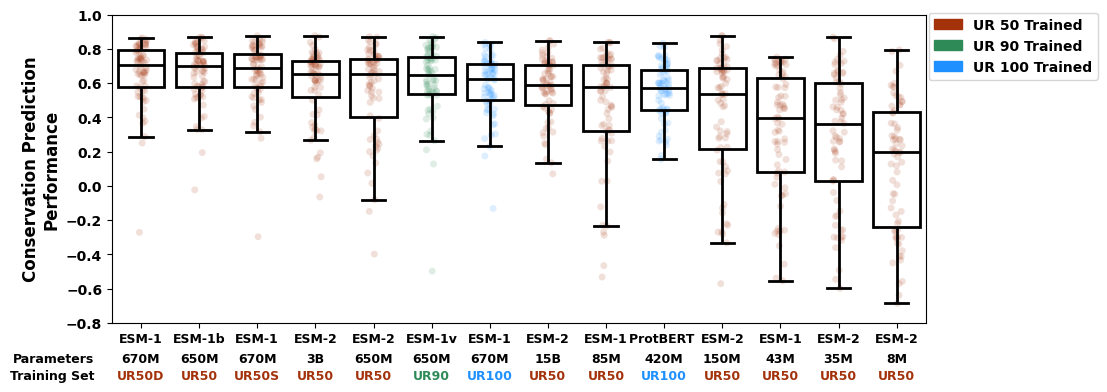

In [10]:
fig, ax = plt.subplots(figsize = (10.5,4))

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.15,
    palette = my_pal
)

ax.text(-0.8, -0.97, "Parameters",horizontalalignment = "right", fontsize = 9, fontweight = "bold",  verticalalignment = "top")
ax.text(-0.8, -1.07, "Training Set", horizontalalignment = "right", fontsize = 9,  verticalalignment = "top", fontweight = "bold")

for i, (m_name, _) in enumerate(model_to_median_entropy.items()):
    
    ax.text(i, -0.97, params_str_list[i], fontweight = "bold", horizontalalignment = "center", fontsize = 9,  verticalalignment = "top")

    ax.text(i, -1.07, dataset_str_list[i], color = text_color_list[i], fontweight = "bold", horizontalalignment = "center", fontsize = 9,  verticalalignment = "top")

red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')

ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.72,0.53,0.5,0.5), prop = {"weight" : "bold"})




ax.set_xticklabels(x_ticklabels, fontsize = 9, fontweight = "bold")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

# 
ax.set_ylabel("Conservation Prediction\nPerformance", fontsize = 12, fontweight = "bold")


save_figure(fig, "boxplot_vogelstein_14_models", root_path=figure_path_2)


(0.0, 4.3)

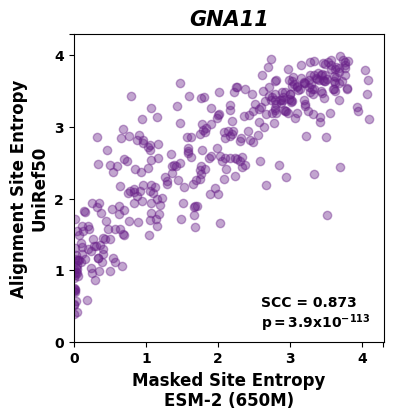

In [11]:
fig, ax = plt.subplots(figsize = (4,4))


model_of_interest = "esm_2_650M"

gene_of_interest = conservation_df.loc[conservation_df["model"] == "esm_2_650M"].sort_values(by = "spearman r", ascending = False).iloc[0]["gene"]

mlm_site_entropy = model_to_protein_site_entropy[model_of_interest][gene_of_interest]
aln_site_entropy = dataset_to_protein_site_entropy[model_to_dataset[model_of_interest]][gene_of_interest]

x = []
y = []

for k, v in aln_site_entropy.items():
    y.append(v)
    x.append(mlm_site_entropy[k])
    
    
corr, p = scipy.stats.spearmanr(x,y)
    
ax.scatter(x,y,color = "#671e87", alpha = 0.4)
ax.set_xticks([0,1,2,3,4,4.3])
ax.set_yticks([0,1,2,3,4,4.3])
ax.set_xticklabels(["0","1","2","3","4",""], fontweight='bold')
ax.set_yticklabels(["0","1","2","3","4",""], fontweight='bold')
ax.set_xlabel("Masked Site Entropy\n" + model_to_base_string[model_of_interest] + " (" +  model_to_params_string[model_of_interest] + ")", fontweight='bold', fontsize = 12)
ax.set_ylabel("Alignment Site Entropy\n" + "UniRef50", fontsize = 12, fontweight = "bold")
ax.set_title(gene_of_interest, fontsize = 15, fontstyle='italic', fontweight='bold')

ax.text(2.6, 0.5, r"SCC = " + str(round(corr, 3)), fontsize = 10, fontweight = "bold")
ax.text(2.6, 0.2, r"$\mathbf{p=" + format_p(p) + "}$", fontsize = 10, fontweight = "bold")

ax.set_xlim(left = 0)
ax.set_ylim(bottom = 0)



# save_figure(fig, "conservation_GNA11", root_path=figure_path_2)


In [12]:
vogelstein = pd.read_csv(llm_review_path + "data/Vogelstein2013_125drivers_sequences.csv", index_col = 0)
(119 - 72) / 119 

0.3949579831932773

In [13]:
acmg = pd.read_csv(llm_review_path + "/data/ACMG_73_sequences.csv")

len(acmg.loc[acmg["Length"] > 1022]) / len(acmg)

0.3287671232876712

In [14]:
len(acmg.loc[acmg["Length"] > 1022]) 

24

In [15]:
large_model  = "esm_2_15B"
small_model  = "esm_2_150M"

small_model_results = conservation_df.loc[conservation_df["model"] == small_model]
large_model_results = conservation_df.loc[conservation_df["model"] == large_model]

median_homs = np.median(small_model_results["homologs_UR50"].values)

few_hom_genes = small_model_results.loc[small_model_results["homologs_UR50"] < median_homs]["gene"].values
many_hom_genes = small_model_results.loc[small_model_results["homologs_UR50"] >= median_homs]["gene"].values


/tmp/ipykernel_125619/2208876502.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


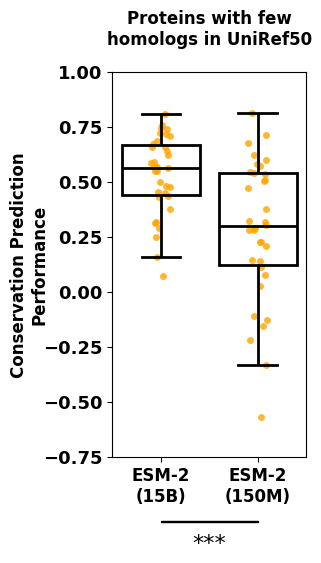

In [24]:

fig, ax = plt.subplots(figsize = (2.5, 5))


y1 = large_model_results.loc[large_model_results["gene"].isin(few_hom_genes)]["spearman r"].values
y2 = small_model_results.loc[small_model_results["gene"].isin(few_hom_genes)]["spearman r"].values




data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.8,
    color = "orange"
)

ax.set_yticks(list(np.arange(-0.75,1.1,0.25)))
# ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold")
ax.set_xticklabels(
    ["ESM-2\n(15B)", "ESM-2\n(150M)"],
    fontsize = 12, fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)

st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")


# ax.text(0.5, -0.29, "MWU $p = " + format_p(p) +  "$", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 16, transform = ax.transAxes, horizontalalignment = "center")

ax.set_title("Proteins with few\nhomologs in UniRef50", fontsize = 12, y = 1.05, fontweight = "bold")
ax.set_ylabel("Conservation Prediction\nPerformance", fontsize = 12, labelpad = -4, fontweight = "bold")


save_figure(fig, "few_homologs_esm_model_comparison_conservation")


In [25]:
st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")
p

2.56876228377223e-06

/tmp/ipykernel_125619/1044937945.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


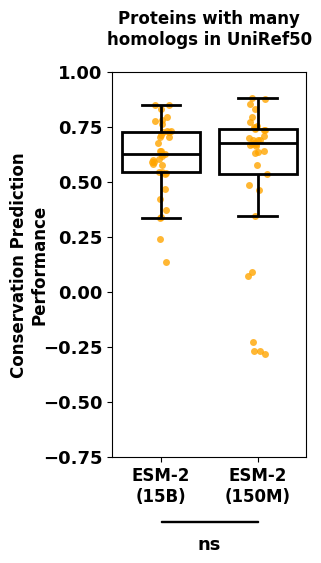

In [26]:

fig, ax = plt.subplots(figsize = (2.5, 5))

y1 = large_model_results.loc[large_model_results["gene"].isin(many_hom_genes)]["spearman r"].values
y2 = small_model_results.loc[small_model_results["gene"].isin(many_hom_genes)]["spearman r"].values

data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.8,
    color = "orange"
)

ax.set_yticks(list(np.arange(-0.75,1.1,0.25)))
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13,fontweight = "bold")
ax.set_xticklabels(
    ["ESM-2\n(15B)", "ESM-2\n(150M)"],
    fontsize = 12,fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)

st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")


# ax.text(0.5, -0.29, "MWU $p = " + format_p(p) +  "$", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 13,fontweight = "bold", transform = ax.transAxes, horizontalalignment = "center")

ax.set_title("Proteins with many\nhomologs in UniRef50", fontsize = 12,fontweight = "bold", y=1.05)
ax.set_ylabel("Conservation Prediction\nPerformance", fontsize = 12, labelpad = -4,fontweight = "bold")
save_figure(fig, "many_homologs_esm_model_comparison_conservation")


In [27]:
st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")
p

0.6341854664206039

'esm_1_43M'
'esm_1_85M'
'esm_1_UR50'
'esm_1_UR50D'
'esm_1b'
'esm_2_150M'
'esm_2_15B'
'esm_2_35M'
'esm_2_3B'
'esm_2_650M'
'esm_2_8M'
{'esm_1_43M': '#A3320B', 'esm_1_UR100': 'dodgerblue', 'esm_1v': 'seagreen', 'esm_2_35M': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_3B': '#A3320B', 'protbert': 'dodgerblue', 'esm_1b': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_2_650M': '#A3320B'}
0.6802419450904404


/tmp/ipykernel_3021957/798899572.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3021957/798899572.py:126: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(label, fontweight = "bold")


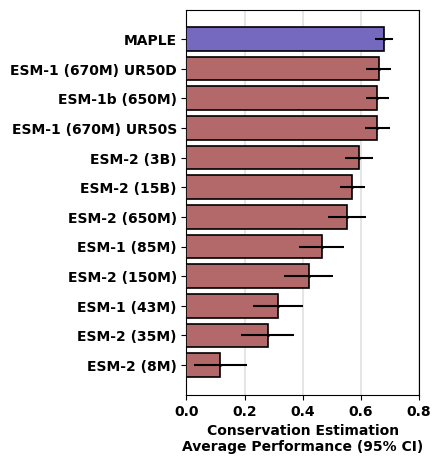

In [21]:

model_to_label_1 = {
    'esm_1_43M' : "ESM-1 (43M)",
    'esm_1_85M': "ESM-1 (85M)",
    'esm_1_UR50':"ESM-1 (670M) UR50S",
    'esm_1_UR50D':"ESM-1 (670M) UR50D",
    'esm_1_UR100':"ESM-1 (670M)",
    'esm_1b':"ESM-1b (650M)",
    'esm_1v':"ESM-1v (650M)",
    'esm_2_150M':"ESM-2 (150M)",
    'esm_2_15B':"ESM-2 (15B)",
    'esm_2_35M':"ESM-2 (35M)",
    'esm_2_3B':"ESM-2 (3B)",
    'esm_2_650M':"ESM-2 (650M)",
    'esm_2_8M':"ESM-2 (8M)",
    'protbert':"ProtBERT (420M)",
    "combined" : "MAPLE"
}


models = set(conservation_df["model"])


summary_df_1 = {}
for m, sub_df in conservation_df.groupby("model"):
    s = pd.Series(sub_df["spearman r"].values, sub_df["gene"].values, ) 
    summary_df_1[m] = s

summary_df_1 = pd.DataFrame.from_dict(summary_df_1)
summary_df_1 = summary_df_1.loc[summary_df_1.index != "DAXX"]

summary_df_1 = summary_df_1.sample(frac = 1)
entropy_df = {m : {} for m in model_to_protein_site_entropy.keys()}

for m, gene_vals in model_to_protein_site_entropy.items():
    model_results = {}
    for gene_id, gene_position_dict in gene_vals.items():
        gene_mean_entropy = np.mean(list(gene_position_dict.values()))
        model_results[gene_id] = gene_mean_entropy
        
    entropy_df[m] = model_results


moe_results = {}
moe_choices = {}
moe_entropies = {}

entropy_df = pd.DataFrame(entropy_df)
entropy_df = entropy_df.loc[entropy_df.index!="DAXX"]
entropy_df = entropy_df.drop(columns = ["esm_1v", "protbert", "esm_1_UR100"])

gamma = 1.3

for identifier, row in entropy_df.iterrows():

    ordered_models = list(row.index)

    dist_from_optimal_entropy = np.abs(row.values - gamma)
    min_dist_index = np.argmin(dist_from_optimal_entropy)

    chosen_model = ordered_models[min_dist_index]
    chosen_model_score = summary_df_1.loc[identifier][chosen_model]
    moe_results[identifier] = chosen_model_score
    moe_choices[identifier] = chosen_model
    moe_entropies[identifier] = row[chosen_model]
    


fig, ax = plt.subplots(figsize = (3,5))



data_df = []

m, ci_l, ci_u = mean_confidence_interval(list(moe_results.values()))
data_df.append(["combined", m, ci_l, ci_u])

for col in summary_df_1.columns:
    if col in ["esm_1v", "protbert", "esm_1_UR100"]:
        continue 
    print("\'" + col + "\'")
    lst = summary_df_1[col].values 
    m, ci_l, ci_u = mean_confidence_interval(lst)
    data_df.append([col, m, ci_l, ci_u])
    
data_df = pd.DataFrame(data_df, columns = ["model", "mean", "ci_l", "ci_u"])

data_df = data_df.sort_values(by = "mean", ascending = False)

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in data_df.iterrows():
    res.append(row["mean"])
    
    label.append(model_to_label_1[row["model"]])
    y.append(c)
    err_vals.append(row["mean"] - row["ci_l"])
    if row["model"] == "combined":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color[row["model"]]
        if color == "#A3320B":
            color = "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0,0.2,0.4,0.6,0.8])
ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_xlim(left = 0, right = 0.8)

ax.scatter(res, y, color = "black", s = 1)
ax.errorbar(res, y, xerr = err_vals, fmt = ".", zorder = 1000, markersize = 1, color = "black")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)


ax.set_xlabel("Conservation Estimation\nAverage Performance (95% CI)", fontweight = "bold")
ax.set_yticklabels(label, fontweight = "bold")

print(model_to_color)
print(np.mean(list(moe_results.values())))



In [66]:
combined_score = res[0]
highest_alt = res[1]

pct_increase = (combined_score - highest_alt) / highest_alt

print("pct increase", pct_increase)

z_val = np.std(res[1:])

print(z_val)

print("z increase", (combined_score - highest_alt) / z_val)


pct increase 0.02866092047290765
0.17197134219020022
z increase 0.11021107033228592


In [67]:
# conservation_df 

display_names_a = {
    "protbert" : "ProtBERT", 
    "esm_1_43M" : "ESM-1 (43M)",
    "esm_1_85M" : "ESM-1 (85M)",
    "esm_1_UR50" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1b" : "ESM-1b",
    "esm_1v" : "ESM-1v",
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" :"ESM-2 (35M)",
    "esm_2_150M" :"ESM-2 (150M)",
    "esm_2_650M" :"ESM-2 (650M)",
    "esm_2_3B" :"ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}

dataset_to_display_names_a = {"homologs_UR50" : "UniRef50", "homologs_UR100" : "UniRef100", "homologs_UR90" : "UniRef90"}

table_a =  copy.deepcopy(conservation_df)
table_a["Task"] = "Site Conservation Estimation"
table_a = table_a[["gene", "Task", "model", "spearman r"]]
table_a = table_a.rename(columns = {"gene" : "Identifier", "model" : "Model", "spearman r" : "Performance"})
table_a["Model"] = table_a["Model"].apply(lambda x : display_names_a[x])
table_a.to_csv(supp_table_path + "all_model_performance_conservation.csv", index = False)



table_b = copy.deepcopy(conservation_df)
table_b["Task"] = "Site Conservation Estimation"
table_b = table_b.loc[table_b["model"] == "protbert"] # homologs will be the same repeated for all models, can choose any model for this table 
table_b = table_b[["gene", "Task", "homologs_UR50","homologs_UR90","homologs_UR100"]]
table_b = table_b.rename(columns = dataset_to_display_names_a).rename(columns = {"gene" : "Identifier"})
table_b.to_csv(supp_table_path + "homologs_all_datasets_conservation.csv" , index = False)


table_c = []
for hom_col, dsn in dataset_to_display_names_a.items():
    for model, display_model in display_names_a.items():
        sub_df = conservation_df.loc[
            conservation_df["model"] == model
        ]
        
        x = sub_df[hom_col].values
        y = sub_df["spearman r"].values
        
        corr, p = scipy.stats.spearmanr(x,y)
        table_c.append([display_model, "Site Conservation Estimation", dsn , corr, p ])
        
        
        
table_c = pd.DataFrame(table_c, columns = ["Model", "Task", "Dataset", "Spearman Correlation", "Spearman p-value"])       
table_c.to_csv(supp_table_path + "homologs_v_performance_all_models_all_datasets_conservation.csv", index = False)


table_d = copy.deepcopy(conservation_df)
table_d["Task"] = "Site Conservation Estimation"
table_d["Model"] = table_d["model"].apply(lambda x : display_names_a[x])
table_d = table_d.rename(columns = {"gene" : "Identifier", "mean_masked_entropy" : "Average Site Entropy"})
table_d = table_d[["Task", "Identifier", "Model",  "Average Site Entropy"]]
table_d = table_d.sort_values(by = "Identifier")
table_d.to_csv(supp_table_path + "average_site_entropy_conservation.csv", index = False)



table_e = []
for k, v in moe_results.items():
    table_e.append([k, "Site Conservation Estimation", v, display_names_a[moe_choices[k]], moe_entropies[k]])

table_e = pd.DataFrame(table_e, columns = ["Identifier", "Task", "Optimal Model Performance", "Optimal Model Choice", "Optimal Model Average Site Entropy"])
table_e.to_csv(supp_table_path + "entropy_optimal_model_choices_conservation.csv")

/tmp/ipykernel_3021957/3982695161.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


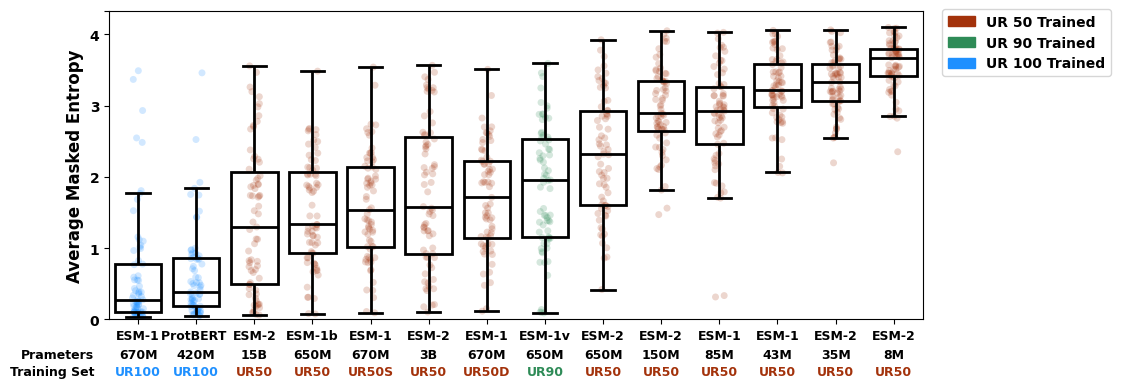

In [96]:
models = set(conservation_df["model"])


summary_df_1 = {}
for m, sub_df in conservation_df.groupby("model"):
    s = pd.Series(sub_df["spearman r"].values, sub_df["gene"].values, ) 
    summary_df_1[m] = s

summary_df_1 = pd.DataFrame.from_dict(summary_df_1)
summary_df_1 = summary_df_1.loc[summary_df_1.index != "DAXX"]

summary_df_1 = summary_df_1.sample(frac = 1)
entropy_df = {m : {} for m in model_to_protein_site_entropy.keys()}

for m, gene_vals in model_to_protein_site_entropy.items():
    model_results = {}
    for gene_id, gene_position_dict in gene_vals.items():
        gene_mean_entropy = np.mean(list(gene_position_dict.values()))
        model_results[gene_id] = gene_mean_entropy
        
    entropy_df[m] = model_results


moe_results = {}
entropy_df = pd.DataFrame(entropy_df)
entropy_df = entropy_df.loc[entropy_df.index!="DAXX"]


m_to_median_entropy = {m : np.median(entropy_df[m].values) for m in entropy_df.columns}
m_to_median_entropy = sort_dict_by_value(m_to_median_entropy)


x = []
data = []
x_ticklabels = []

my_pal = []

i = 0
for m, v in m_to_median_entropy.items():
   
    x.append(i)
    x_ticklabels.append(model_to_base_string[m])
    data.append(entropy_df[m].values)
    my_pal.append(model_to_color[m])
    i += 1
    
fig, ax = plt.subplots(figsize = (10.5,4))

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.2,
    color = "lightsteelblue",
    palette = my_pal
)

ax.set_ylabel("Average Masked Entropy", fontsize = 12, fontweight = "bold")
ax.set_xticks(x)
ax.set_xticklabels(
    x_ticklabels, 
    fontsize = 9, 
    fontweight = "bold"
)
x_i = 0
for i, k in enumerate(m_to_median_entropy.keys()):
    if k == "protbert_bfd":
        continue 
    ax.text(x_i, -0.55, model_to_params_string[k], fontsize = 9, horizontalalignment = "center", fontweight = "bold")
    ax.text(x_i, -0.78,model_to_dataset_string[k].replace("-", ""), fontsize = 9 , horizontalalignment = "center", color=model_to_color[k] , fontweight = "bold")
    x_i += 1

    
    
ax.text(-0.75, -0.55, "Prameters", fontsize = 9, horizontalalignment = "right", fontweight = "bold")
ax.text(-0.75, -0.78, "Training Set", fontsize = 9, horizontalalignment = "right", fontweight = "bold")

ent_ticks= [0,1,2,3,4,4.322]
ent_labels = ["0", "1","2","3","4", ""]
ax.set_yticks(ent_ticks)
ax.set_yticklabels(ent_labels, fontweight = "bold")



ax.set_ylim(bottom = 0, top = 4.322)
red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')

ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.74,0.53,0.5,0.5), prop = {"weight" : "bold"})

